# Reverse Engineering API

## Introduction

🔍 **Introduction to Reverse Engineering APIs**

Before we dive into scraping, let’s understand how a modern website works.

A website generally has two main parts:
1. Frontend – what you see in your browser (HTML, CSS, JavaScript).
2. Backend – the server-side logic that handles data and responds to requests.

Whenever you browse a website and see data, like product lists, prices, or user information. That data is not hardcoded in the frontend. Instead, it's fetched from the backend, usually through an API.

🧠 **Think of an API as a bridge**

The API acts as a bridge between the frontend and the backend. It delivers data (usually in JSON format) to the frontend, which then displays it nicely on the screen.

🔄 **Why Reverse Engineer the API?**

Traditional web scraping involves selecting elements using CSS selectors (like div.title or span.price). While this works, it's:
- Fragile (any UI update can break your scraper)
- Inefficient (you scrape HTML and then parse the data manually)

Instead, we can reverse engineer the API, find out what requests the frontend is making, and hit that endpoint directly using tools like requests. This way, we:
- Get structured data directly (usually in JSON)
- Avoid parsing HTML
- Reduce the chance of errors due to frontend changes

Once you’ve identified the hidden API, try scraping it using the basic requests library.

In [14]:
import requests

url = "https://cekbpom.pom.go.id/produk-dt/01"
response = requests.post(url)
print(response)
if response.status_code == 200:
    data = response.json()
    print(data)

<Response [419]>


## The importance of TLS Fingerprinting

🚨 Why is TLS Fingerprinting Important?
1. **Bot Detection**:
Websites frequently use TLS fingerprinting to identify bots and automation tools. If your scraper doesn’t match the fingerprint of a real browser (like Chrome or Firefox), it can easily be flagged or blocked.
2. **Security Monitoring**:
From a security perspective, TLS fingerprints help detect suspicious traffic patterns, such as botnets or unusual clients within a network.

✅ What Can We Do?
1. **Bypass Anti-Bot Measures**: 
By spoofing or mimicking the TLS fingerprints of real browsers, scrapers can blend in more effectively and avoid detection.

For mimicking TLS fingeprinting, there're lots of library we can use. Top 3 are:
- curl-cffi (https://pypi.org/project/curl-cffi/)
- tls-client (https://pypi.org/project/tls-client/)
- rnet (https://pypi.org/project/rnet/)

In this tutorial, we're going to us curl-cffi

In [15]:
from curl_cffi import requests

url = "https://cekbpom.pom.go.id/produk-dt/01"
response = requests.post(url)
print(response)
if response.status_code == 200:
    data = response.json()
    print(data)

<Response [419]>


Sometimes, simply mimicking a real browser’s TLS fingerprint is enough to bypass anti-bot protections. However, in more advanced cases—like the one we encountered here—that alone may not work. In such situations, it's crucial to upgrade your scraper's capabilities.

👉 **Important to note**: always be aware of TLS Fingerprinting. In my opinion, handling it properly is a must for any reliable scraping setup. As a best practice, consider replacing the standard requests library with more stealth-oriented clients like curl-cffi, tls-client, or rnet. These tools help emulate real browser behavior more accurately and significantly increase your chances of staying undetected.

## The importance of a Header

If we look at the error message, it shows a 419 error. A "419 error" typically indicates a Cross-Site Request Forgery (CSRF) token mismatch, which often occurs when a user's session expires or the CSRF token is invalid.

Now, let's go back to the Dev Tools to examine it in more detail.

Go to the Network tab, then select the Headers tab. Inside the Headers tab, click on **Request Headers**. Here, we can see the CSRF token.

Since we're making the request outside of the browser, we don't have this CSRF token — which is why we're receiving the 419 error. The root cause may vary, but this is a good place to start our investigation.

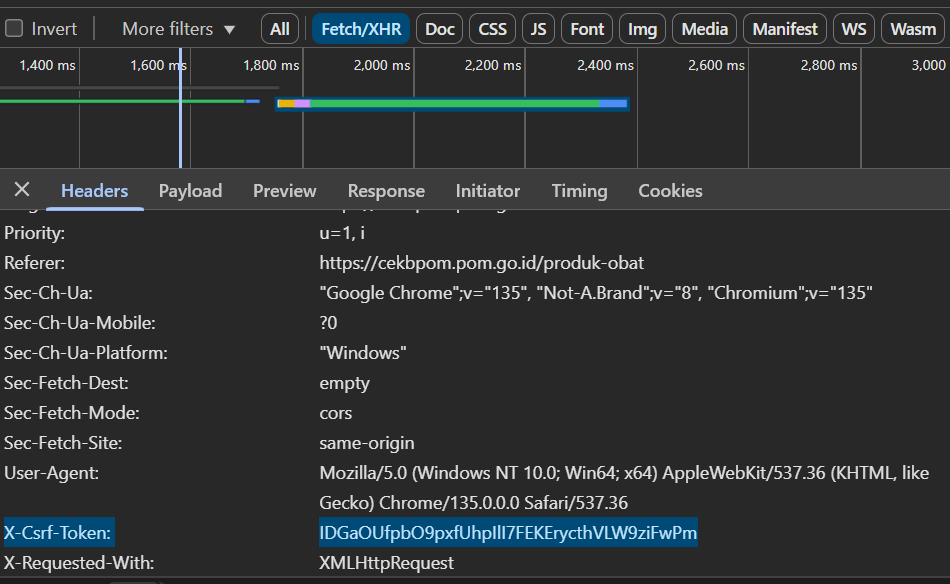

Now, let’s see what happens if we try making the request using this header — will it solve the problem? Let’s give it a try and find out. Here’s the step-by-step process we’re going to follow:

1. Right-click on the API request
2. Select Copy as cURL (bash)
3. Go to https://curlconverter.com/
4. Paste the cURL command
5. Copy the generated Python code and paste it here

In [31]:
# from curl_cffi import requests

import requests

headers = {
    'accept': 'application/json, text/javascript, */*; q=0.01',
    'accept-language': 'en-US,en;q=0.9',
    'content-type': 'application/x-www-form-urlencoded; charset=UTF-8',
    'origin': 'https://cekbpom.pom.go.id',
    'priority': 'u=1, i',
    'referer': 'https://cekbpom.pom.go.id/produk-obat',
    'sec-ch-ua': '"Google Chrome";v="135", "Not-A.Brand";v="8", "Chromium";v="135"',
    'sec-ch-ua-mobile': '?0',
    'sec-ch-ua-platform': '"Windows"',
    'sec-fetch-dest': 'empty',
    'sec-fetch-mode': 'cors',
    'sec-fetch-site': 'same-origin',
    'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/135.0.0.0 Safari/537.36',
    'x-csrf-token': 'IDGaOUfpbO9pxfUhpIlI7FEKErycthVLW9ziFwPm',
    'x-requested-with': 'XMLHttpRequest',
}

data = {
    'draw': '1',
    'columns[0][data]': 'PRODUCT_ID',
    'columns[0][name]': '',
    'columns[0][searchable]': 'false',
    'columns[0][orderable]': 'false',
    'columns[0][search][value]': '',
    'columns[0][search][regex]': 'false',
    'columns[1][data]': 'PRODUCT_REGISTER',
    'columns[1][name]': '',
    'columns[1][searchable]': 'false',
    'columns[1][orderable]': 'false',
    'columns[1][search][value]': '',
    'columns[1][search][regex]': 'false',
    'columns[2][data]': 'PRODUCT_NAME',
    'columns[2][name]': '',
    'columns[2][searchable]': 'false',
    'columns[2][orderable]': 'false',
    'columns[2][search][value]': '',
    'columns[2][search][regex]': 'false',
    'columns[3][data]': 'MANUFACTURER_NAME',
    'columns[3][name]': '',
    'columns[3][searchable]': 'false',
    'columns[3][orderable]': 'false',
    'columns[3][search][value]': '',
    'columns[3][search][regex]': 'false',
    'order[0][column]': '0',
    'order[0][dir]': 'asc',
    'start': '0',
    'length': '100',
    'search[value]': '',
    'search[regex]': 'false',
    'product_register': '',
    'product_name': '',
    'product_brand': '',
    'product_package': '',
    'product_form': '',
    'ingredients': '',
    'submit_date': '',
    'product_date': '',
    'expire_date': '',
    'manufacturer_name': '',
    'status': '',
    'release_date': '',
}

headers = {'host': 'cekbpom.pom.go.id', 'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:135.0) Gecko/20100101 Firefox/135.0', 'accept': 'application/json, text/javascript, */*; q=0.01', 'accept-language': 'en-US,en;q=0.5', 'accept-encoding': 'gzip, deflate, br, zstd', 'content-type': 'application/x-www-form-urlencoded; charset=UTF-8', 'x-csrf-token': 'wgwvqRff3Kzwb8lz6BhhODOMRsMefhPPeJ0DrngC', 'x-requested-with': 'XMLHttpRequest', 'origin': 'https://cekbpom.pom.go.id', 'connection': 'keep-alive', 'referer': 'https://cekbpom.pom.go.id/produk-obat', 'cookie': 'XSRF-TOKEN=eyJpdiI6IjM0eGtmK2tNYzljQUJLWlJRc01vd2c9PSIsInZhbHVlIjoieXQvTUQ2TnF2bDZjaWVEUGlaTExXWDJhZkVCWGl4ankxTUZYT1ZlUGl1VlhTdENsMi9oTG9xd05kRlI3d252YUNJTGIrY25ScTVNcGtaSm5aMXRjN1JGdFB2eXZ6L25LN1g2Zm1WSDNvallYQWVVR1ZPVjh6dmtrNlFlRjE1TlAiLCJtYWMiOiI4NTg1MTAwNTM0N2EyNzQ3NmFlZDA4MDNhMDNlNzI3Yzc1NWZjNGVhMzA1YzRkMDQyM2JiMDNhMzM4NzY4ZGQ5IiwidGFnIjoiIn0%3D; webreg_session=eyJpdiI6IlFuWHVFdEI2NStoUEY5T0xSWm81YUE9PSIsInZhbHVlIjoiWVhOam1lZXhhRmNNQzBseFRRQk11V2xsOW03aVgvckpPK3hHeTc0L1RkQUlzTTJERXpVSVEvcjZZQ1Zrc1VMemt3cXAwQ285ZThRZ2wxZnBvOGU0MTZQbDhYL3liTDgrRUhGN2pDaE5VMG5NdmhrVUFGYUgvTVhod3NDdmlLVVciLCJtYWMiOiJmZDQxMmQ3OWZiMWI0Y2YyOTE4MDA4OTIxMTAwYjlhN2Y3ZmU0YzM4NTE5ZjlmMjBjMWVlZTc5MWQ2MTViMmY2IiwidGFnIjoiIn0%3D', 'sec-fetch-dest': 'empty', 'sec-fetch-mode': 'cors', 'sec-fetch-site': 'same-origin'}
response = requests.post('https://cekbpom.pom.go.id/produk-dt/01', headers=headers, data = data)
data = response.json()
data

{'draw': 1,
 'recordsTotal': 11238,
 'recordsFiltered': 11238,
 'data': [{'ID': 587096,
   'PRODUCT_ID': 'EREG100255VR12400211',
   'CLASS': '01',
   'CLASS_ID': '01',
   'APPLICATION': 'newaero',
   'APPLICATION_ID': '05',
   'PRODUCT_REGISTER': 'GKL1815627401A2',
   'PRODUCT_NAME': 'CLINDAMYCIN HYDROCHLORIDE',
   'PRODUCT_BRANDS': '-',
   'PRODUCT_PACKAGE': 'DUS, 10 BLISTER @ 10 KAPSUL',
   'PRODUCT_FORM': 'KAPSUL',
   'STATUS': 'Berlaku',
   'REGISTRAR_ID': '255',
   'IMPORTER_ID': None,
   'DELETED_DATE': None,
   'STATUS_COMMITMENT': None,
   'KATEGORI_DOKUMEN': None,
   'PRODUCT_ATC': 'J01',
   'PRODUCT_QR': '(90)GKL1815627401A2',
   'PRODUCT_FILE': None,
   'PRODUCT_REVISION': None,
   'MESSAGE': None,
   'SUBMIT_DATE': '2025-04-09',
   'PRODUCT_UPDATE': '2025-04-09',
   'PRODUCT_DATE': '2025-04-03',
   'PRODUCT_EXPIRED': '2030-04-03',
   'DEPARTMENT_ID': '210',
   'USER_NAME': 'Lika Nur Annisa, A.Md',
   'REGISTRAR': 'MEPROFARM - Indonesia',
   'REGISTRAR_ADD': 'JL. SOEKARNO HA

Yay, it's working. Now let's try to see the data

In [12]:
drug_list  = data['data']
print('There are', len(drug_list),'drugs')
for drug in drug_list:
    print(drug['PRODUCT_NAME'])

There are 1000 drugs
ALLOPURINOL
ACTOS
WOODS PEPPERMINT EXPECTORANT
PYRIDOL
LACTRIN
DOME
TB VIT 6
SOROQUIN XR
WOODS PEPPERMINT EXPECTORANT
SYTIN
AKILEN
PANLOC
METRONIDAZOLE BENZOATE
COXIDA 120
SOROQUIN XR
GAMESOLONE
E-SOME
SANBE HEST 130
VAXIGRIP TETRA NH
L-CISIN
PYRAZINAMIDE
PRITANOL 300
VOXIN
WATER FOR INJECTION
GELOFUSINE
SOROQUIN XR
CEFADROXIL MONOHYDRATE
CLINDAMYCIN HYDROCHLORIDE
YEKAZONE
MICAFAR 50
EKACETOL FORTE
MOMETASONE FUROATE
CLOVERTIL
ALBOTHYL
GAMESOLONE
FORIFEK FORTE
BETADINE VAGINAL DOUCHE
PARACETAMOL
MICAFAR 100
VALPROIC ACID
SOROQUIN XR
WATER FOR INJECTION
SOROQUIN XR
MEFINTER 500
COXIDA 60
FLACOID-0,5
ARCAPEC
TOMAAG
MICAFUNGIN SODIUM
VERTIGOSAN
GUAIFENESIN
COXIDA 90
MICAFUNGIN SODIUM
RESFAR
TUSSELIX
PHENOMED
IFARSYL
FASIDOL
BLEDSTOP
VOXIN
SPIRONOLACTONE
LEPTICA 75
ONETIC 4
ALUGEN 300
SITHIAM 500
SOROQUIN XR
PRITANOL 100
CINOLON-N
ONDANSETRON HYDROCHLORIDE DIHYDRATE
ORPHEN
PANTOPRAZOLE SODIUM
DUMIN
ALUGEN 100
CEFADROXIL MONOHYDRATE
ACTOS
EPHEDRINE HYDROCHLORIDE
ETERFIX

## Process the data with Pydantic

To convert our data into a Pydantic schema, we can use https://jsontopydantic.com.

In [13]:
from pydantic import BaseModel
from typing import Optional

class Drug(BaseModel):
    PRODUCT_ID: Optional[str] = None
    PRODUCT_NAME: Optional[str] = None
    PRODUCT_FORM: Optional[str] = None
    INGREDIENTS: Optional[str] = None
    MANUFACTURER_NAME: Optional[str] = None


for drug in drug_list:
    drug_pydantic = Drug(**drug)
    print(drug_pydantic)

PRODUCT_ID='EREG100019VR12500064' PRODUCT_NAME='ALLOPURINOL' PRODUCT_FORM='TABLET' INGREDIENTS='ALLOPURINOL' MANUFACTURER_NAME='BERNOFARM - Indonesia'
PRODUCT_ID='EREG10023512400133' PRODUCT_NAME='ACTOS' PRODUCT_FORM='TABLET' INGREDIENTS='PIOGLITAZONE HYDROCHLORIDE' MANUFACTURER_NAME='TAKEDA INDONESIA - Indonesia'
PRODUCT_ID='EREG10022112400244' PRODUCT_NAME='WOODS PEPPERMINT EXPECTORANT' PRODUCT_FORM='SIRUP' INGREDIENTS='BROMHEXINE HYDROCHLORIDE&lt;br&gt;GUAIFENESIN' MANUFACTURER_NAME='KALBE FARMA - Indonesia'
PRODUCT_ID='EREG100193VR12400291' PRODUCT_NAME='PYRIDOL' PRODUCT_FORM='TABLET' INGREDIENTS='PARACETAMOL' MANUFACTURER_NAME='PYRIDAM FARMA TBK - Indonesia'
PRODUCT_ID='EREG10029112500044' PRODUCT_NAME='LACTRIN' PRODUCT_FORM='KAPSUL' INGREDIENTS='ERDOSTEINE' MANUFACTURER_NAME='LAPI LABORATORIES - Indonesia'
PRODUCT_ID='EREG100269VR12500009' PRODUCT_NAME='DOME' PRODUCT_FORM='TABLET SALUT SELAPUT' INGREDIENTS='DOMPERIDONE' MANUFACTURER_NAME='PROMEDRAHARDJO FARMASI INDUSTRI - Indones

## Automate Header Retrieval Using Camoufox

1. Visit https://pypi.org/project/camoufox/ and https://camoufox.com/ for more details.
2. Run `pip install camoufox` to install the package.
3. Run `camoufox fetch` to install the required browser driver.

Camoufox essentially automates your browser. If you’ve used Selenium before, you’ll find it familiar. If not, try running `simple_camoufox_example.py` from the terminal to see it in action.

If you've understood how Camoufox works, let's move on to `main/scraper/sync.py`

## Optimization: Using Asynchronous and Parallel Processing

When dealing with web scraping or large-scale data fetching tasks, performance and speed become critical—especially when the number of API calls or pages to process grows rapidly. Traditional synchronous code executes tasks one by one, which can lead to significant delays due to network latency or I/O-bound operations.

By introducing asynchronous and parallel processing, we can:

✅ Reduce waiting time by making multiple requests concurrently

✅ Speed up scraping by utilizing system resources more efficiently

✅ Handle high-volume data pipelines without blocking the main thread

Look at `main/scraper/async.py`

With a synchronous approach, processing approximately 11,000 data entries takes about 95 to 105 seconds.



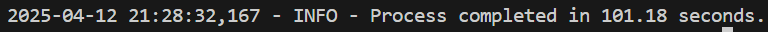







whereas with asynchronous and parallel processing, the same task takes only about 14 to 22 seconds









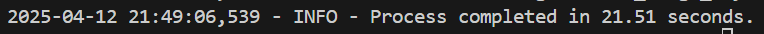